In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip /content/drive/MyDrive/18912306.zip

Archive:  /content/drive/MyDrive/18912306.zip
replace salad_val.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: salad_val.csv           
replace datacard.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: datacard.md             
replace salad_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: salad_train.csv         y
y

replace salad_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:  extracting: salad_test.csv          y

replace stats.json? [y]es, [n]o, [A]ll, [N]one, [r]ename:  extracting: stats.json              


In [3]:
# Import Libraries
import pandas as pd
import numpy as np

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

In [4]:
# Load SALAD Dataset
DATA_PATH = "salad_train.csv"
df = pd.read_csv(
    DATA_PATH,
    nrows=200000)

In [5]:
# Dataset Shape
rows, cols = df.shape

print(f"Number of Rows    : {rows:,}")
print(f"Number of Columns : {cols}")

Number of Rows    : 200,000
Number of Columns : 29


In [6]:
# Dataset Overview
print("First 5 Records")
display(df.head())

First 5 Records


,alert_id,timestamp,source_dataset,src_ip,dst_ip,src_port,dst_port,protocol,flow_duration,total_fwd_packets,total_bwd_packets,flow_bytes_per_sec,alert_type,severity,confidence,mitre_tactic,mitre_technique,kill_chain_phase,network_segment,is_malicious,attack_category,triage_decision,priority_score,difficulty_level,alert_count_1h,alert_count_24h,is_repeated_target,correlation_key,alert_description
0,838a1526-568,2015-01-29T10:44:01,UNSW_NB15,10.18.182.195,192.168.2.113,58106,0,tcp,0.954398,10,8,1.022634e+03,normal_traffic,none,0.1296,-,-,-,workstation,False,Benign,suppress,0.0389,easy,0,0,True,-,Normal network traffic observed from 10.18.182...
1,bc84e2b3-175,2015-02-10T03:28:21,UNSW_NB15,10.56.8.216,192.168.8.95,35504,0,tcp,0.653363,10,8,1.359122e+03,normal_traffic,none,0.1251,-,-,-,workstation,False,Benign,suppress,0.0375,easy,0,0,True,-,Normal network traffic observed from 10.56.8.2...
2,261aa10f-8fc,2015-01-30T19:10:08,UNSW_NB15,10.148.47.156,192.168.4.168,49391,0,udp,0.009182,4,4,9.496842e+04,normal_traffic,none,0.1377,-,-,-,workstation,False,Benign,suppress,0.0413,easy,0,0,True,-,Normal network traffic observed from 10.148.47...
3,53b98d91-198,2015-01-29T04:42:52,UNSW_NB15,10.2.16.116,192.168.6.27,38183,0,tcp,0.555326,14,10,2.394990e+03,normal_traffic,none,0.1764,-,-,-,workstation,False,Benign,suppress,0.0529,easy,0,0,True,-,Normal network traffic observed from 10.2.16.1...
4,807a7a51-6d9,2015-02-03T01:17:23,UNSW_NB15,10.137.218.78,192.168.5.36,44330,0,udp,0.000007,2,0,1.064000e+06,normal_traffic,none,0.3077,-,-,-,workstation,False,Benign,suppress,0.0923,medium,0,0,True,-,Normal network traffic observed from 10.137.21...


In [7]:
# Feature Names
print("\nFeature Names")

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")


Feature Names
01. alert_id
02. timestamp
03. source_dataset
04. src_ip
05. dst_ip
06. src_port
07. dst_port
08. protocol
09. flow_duration
10. total_fwd_packets
11. total_bwd_packets
12. flow_bytes_per_sec
13. alert_type
14. severity
15. confidence
16. mitre_tactic
17. mitre_technique
18. kill_chain_phase
19. network_segment
20. is_malicious
21. attack_category
22. triage_decision
23. priority_score
24. difficulty_level
25. alert_count_1h
26. alert_count_24h
27. is_repeated_target
28. correlation_key
29. alert_description


In [8]:
# Data Types
print("\nData Types")

dtype_df = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

display(dtype_df)


Data Types


,Feature,Data Type
0,alert_id,object
1,timestamp,object
2,source_dataset,object
3,src_ip,object
4,dst_ip,object
5,src_port,int64
6,dst_port,int64
7,protocol,object
8,flow_duration,float64
9,total_fwd_packets,int64


In [9]:
# Missing Values Analysis
print("\nMissing Values")
missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percentage
})

missing_df = missing_df.sort_values(
    by="Missing Count",
    ascending=False
)

display(missing_df)


Missing Values


,Missing Count,Missing Percentage (%)
alert_id,0,0.0
timestamp,0,0.0
source_dataset,0,0.0
src_ip,0,0.0
dst_ip,0,0.0
src_port,0,0.0
dst_port,0,0.0
protocol,0,0.0
flow_duration,0,0.0
total_fwd_packets,0,0.0


In [10]:
# Duplicate Records
print("\nDuplicate Analysis")
duplicate_count = df.duplicated().sum()

duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print(f"Duplicate Rows       : {duplicate_count:,}")
print(f"Duplicate Percentage : {duplicate_percentage:.4f}%")


Duplicate Analysis
Duplicate Rows       : 0
Duplicate Percentage : 0.0000%


In [11]:
# Numerical Features Summary Statistics
print("\nNumerical Summary Statistics")

numerical_summary = (df.describe().transpose())

display(numerical_summary)


Numerical Summary Statistics


,count,mean,std,min,25%,50%,75%,max
src_port,200000.0,3.326098e+04,1.863827e+04,1.024000e+03,17119.750000,33314.00000,49371.250000,6.553400e+04
dst_port,200000.0,9.818860e+02,7.015988e+03,0.000000e+00,0.000000,0.00000,0.000000,6.551400e+04
flow_duration,200000.0,1.204399e+06,1.049386e+07,-1.000000e+00,0.000008,0.02677,1.006932,1.199995e+08
total_fwd_packets,200000.0,1.841306e+01,1.284279e+02,1.000000e+00,2.000000,2.00000,12.000000,1.064600e+04
total_bwd_packets,200000.0,1.677903e+01,1.084090e+02,0.000000e+00,0.000000,0.00000,8.000000,1.097400e+04
flow_bytes_per_sec,200000.0,3.749203e+05,1.042511e+07,-1.200000e+07,3830.947198,114000.00000,200000.000000,2.070000e+09
confidence,200000.0,3.725743e-01,1.615773e-01,5.000000e-02,0.192800,0.42830,0.504100,8.469000e-01
priority_score,200000.0,3.605897e-01,2.651549e-01,1.500000e-02,0.057800,0.52740,0.555400,8.541000e-01
alert_count_1h,200000.0,1.400000e-04,1.183136e-02,0.000000e+00,0.000000,0.00000,0.000000,1.000000e+00
alert_count_24h,200000.0,3.280000e-03,5.769972e-02,0.000000e+00,0.000000,0.00000,0.000000,2.000000e+00


In [12]:
# Numerical Feature List
print("\nNumerical Features")

numerical_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

print(f"Total Numerical Features: {len(numerical_cols)}")

for col in numerical_cols:
    print(col)


Numerical Features
Total Numerical Features: 10
src_port
dst_port
flow_duration
total_fwd_packets
total_bwd_packets
flow_bytes_per_sec
confidence
priority_score
alert_count_1h
alert_count_24h


In [13]:
# Categorical Feature List
print("\nCategorical Features")

categorical_cols = df.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

print(f"Total Categorical Features: {len(categorical_cols)}")

for col in categorical_cols:
    print(col)


Categorical Features
Total Categorical Features: 19
alert_id
timestamp
source_dataset
src_ip
dst_ip
protocol
alert_type
severity
mitre_tactic
mitre_technique
kill_chain_phase
network_segment
is_malicious
attack_category
triage_decision
difficulty_level
is_repeated_target
correlation_key
alert_description


In [14]:
# Categorical Summary Statistics
print("\nCategorical Summary")

categorical_summary = pd.DataFrame({
    "Unique Values":
        df[categorical_cols].nunique(),

    "Most Frequent Value":
        df[categorical_cols].mode().iloc[0],

    "Frequency":
        df[categorical_cols].apply(
            lambda x: x.value_counts().iloc[0]
        )
})

display(categorical_summary)


Categorical Summary


,Unique Values,Most Frequent Value,Frequency
alert_id,200000,00000e19-cc1,1
timestamp,192374,2015-02-07T18:53:31,4
source_dataset,2,UNSW_NB15,180365
src_ip,198804,10.243.76.95,3
dst_ip,2277,192.168.9.68,126
protocol,133,tcp,105811
alert_type,10,normal_traffic,84734
severity,5,none,84734
mitre_tactic,7,-,125943
mitre_technique,9,-,125943


In [15]:
# Unique Values Per Feature
print("\nUnique Values Per Feature")

unique_df = pd.DataFrame({
    "Feature": df.columns,
    "Unique Values": df.nunique().values
})

display(
    unique_df.sort_values(
        by="Unique Values",
        ascending=False
    )
)


Unique Values Per Feature


,Feature,Unique Values
0,alert_id,200000
28,alert_description,200000
3,src_ip,198804
1,timestamp,192374
27,correlation_key,115163
11,flow_bytes_per_sec,101345
8,flow_duration,93025
5,src_port,61719
14,confidence,6287
6,dst_port,4039


In [16]:
# Triage Decision Distribution
print("\nTriage Decision Distribution")

triage_count = (
    df["triage_decision"]
    .value_counts()
)

triage_percentage = (
    df["triage_decision"]
    .value_counts(normalize=True)
    * 100
)

triage_df = pd.DataFrame({
    "Count": triage_count,
    "Percentage (%)": triage_percentage
})

display(triage_df)


Triage Decision Distribution


,Count,Percentage (%)
triage_decision,,
suppress,84734,42.367
investigate,69844,34.922
escalate,45422,22.711


In [17]:
# Malicious Label Distribution
print("\nMalicious Label Distribution")

malicious_count = (
    df["is_malicious"]
    .value_counts()
)

malicious_percentage = (
    df["is_malicious"]
    .value_counts(normalize=True)
    * 100
)

malicious_df = pd.DataFrame({
    "Count": malicious_count,
    "Percentage (%)": malicious_percentage
})

display(malicious_df)


Malicious Label Distribution


,Count,Percentage (%)
is_malicious,,
True,115266,57.633
False,84734,42.367


In [18]:
# Priority Score Overview
print("\nPriority Score Statistics")

display(
    df["priority_score"]
    .describe()
)


Priority Score Statistics


,priority_score
count,200000.000000
mean,0.360590
std,0.265155
min,0.015000
25%,0.057800
50%,0.527400
75%,0.555400
max,0.854100


In [19]:
# Difficulty Level Distribution
print("\nDifficulty Level Distribution")

difficulty_df = pd.DataFrame({
    "Count":
        df["difficulty_level"].value_counts(),

    "Percentage (%)":
        df["difficulty_level"]
        .value_counts(normalize=True)
        * 100
})

display(difficulty_df)


Difficulty Level Distribution


,Count,Percentage (%)
difficulty_level,,
medium,75348,37.6740
hard,69849,34.9245
easy,54803,27.4015


### EDA

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [21]:
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

In [22]:
# Check invalid timestamps
print("Invalid timestamps:", df["timestamp"].isnull().sum())

Invalid timestamps: 0


In [23]:
# Extract temporal features
df["hour_of_day"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()

In [24]:
# Overview
display(
    df[["timestamp", "hour_of_day", "day_of_week"]].head()
)

,timestamp,hour_of_day,day_of_week
0,2015-01-29 10:44:01,10,Thursday
1,2015-02-10 03:28:21,3,Tuesday
2,2015-01-30 19:10:08,19,Friday
3,2015-01-29 04:42:52,4,Thursday
4,2015-02-03 01:17:23,1,Tuesday


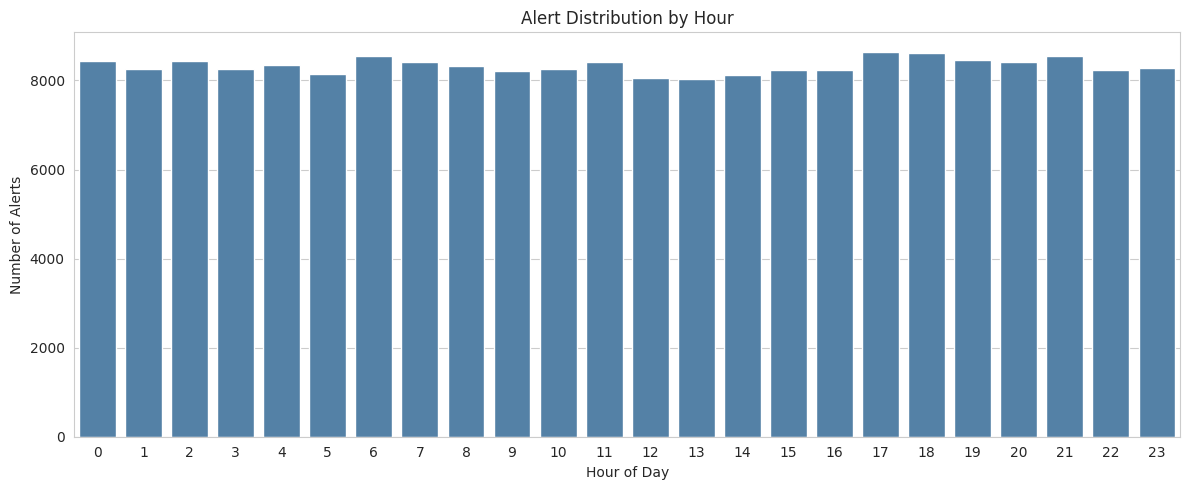

In [25]:
# Alert Distribution by Hour
plt.figure(figsize=(12, 5))
sns.countplot(x="hour_of_day",data=df,color="steelblue")

plt.title("Alert Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Alerts")

plt.tight_layout()
plt.show()

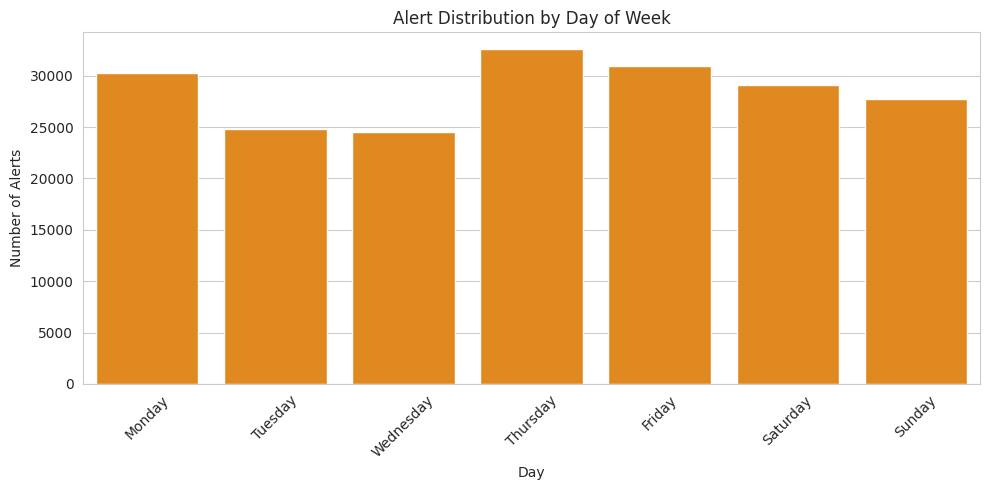

In [26]:
# Alert Distribution by Day of Week
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

plt.figure(figsize=(10, 5))
sns.countplot(x="day_of_week",data=df,order=day_order,color="darkorange")

plt.title("Alert Distribution by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Alerts")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
# Numerical Features
numerical_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical Features:")
print(numerical_cols)

Numerical Features:
['src_port', 'dst_port', 'flow_duration', 'total_fwd_packets', 'total_bwd_packets', 'flow_bytes_per_sec', 'confidence', 'priority_score', 'alert_count_1h', 'alert_count_24h', 'hour_of_day']


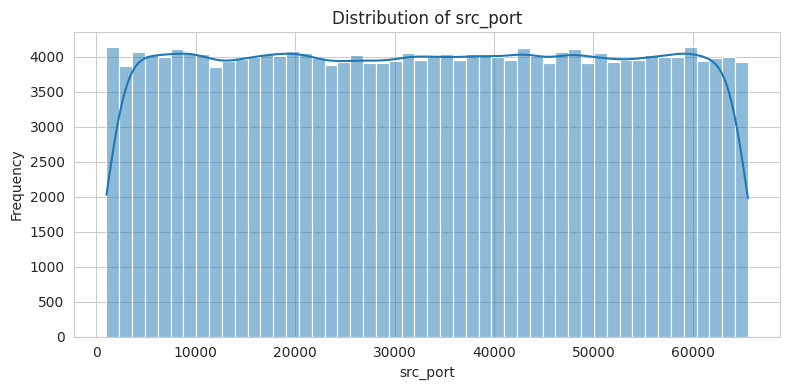

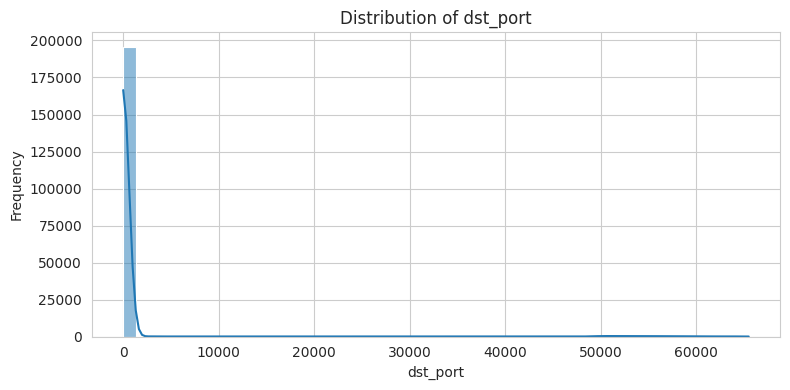

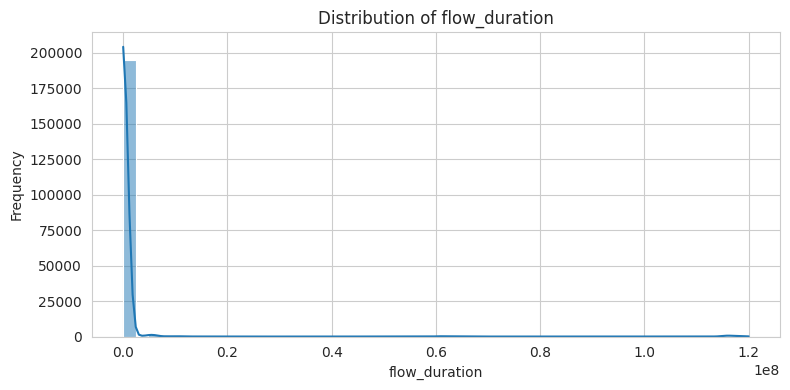

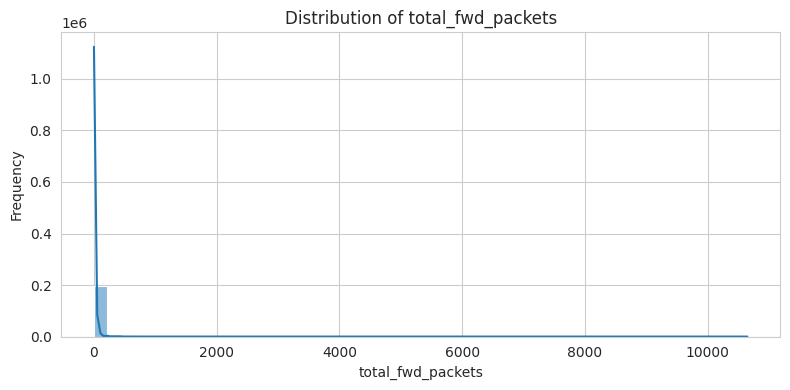

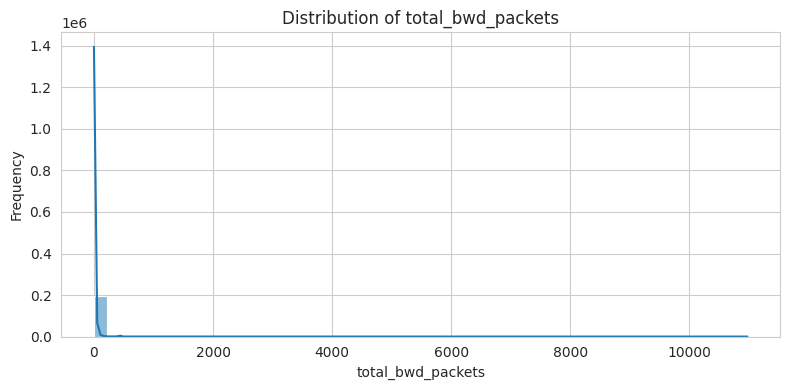

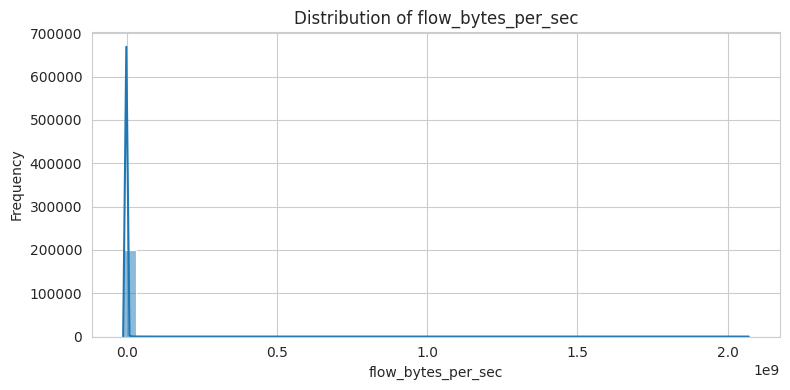

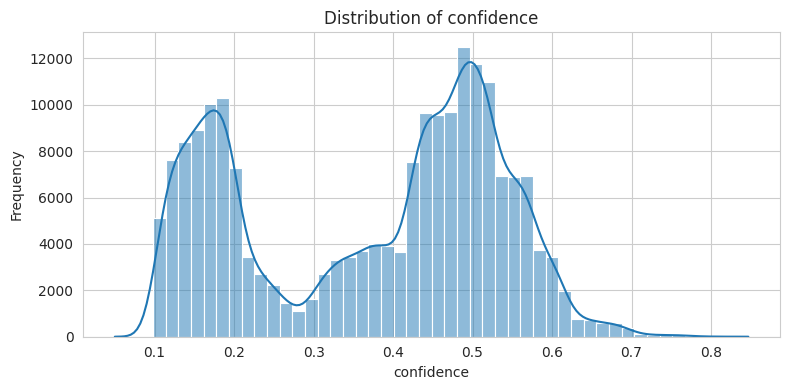

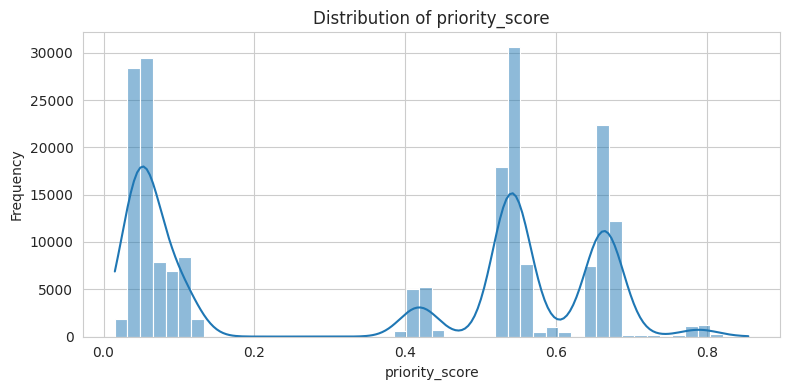

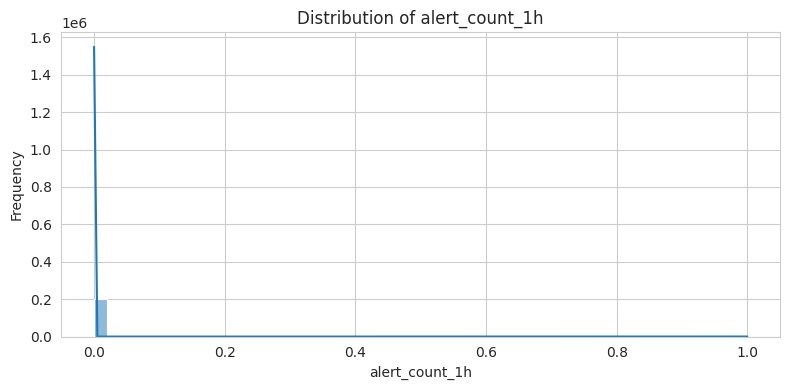

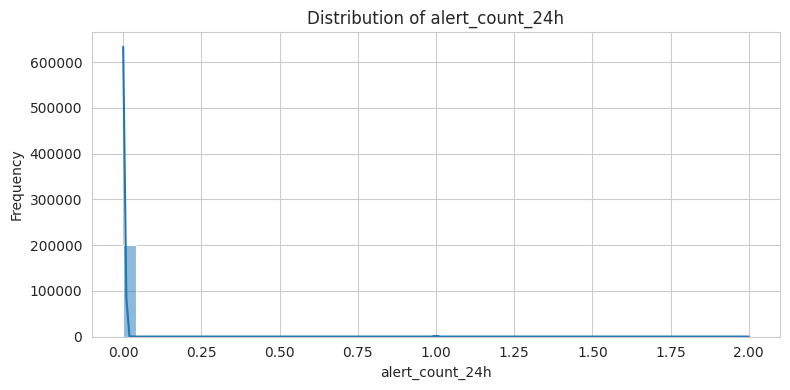

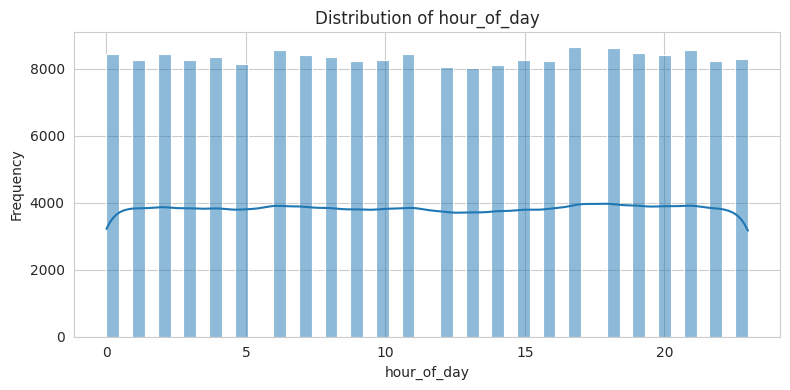

In [28]:
# Distribution of Numerical Features
for column in numerical_cols:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        df[column],
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


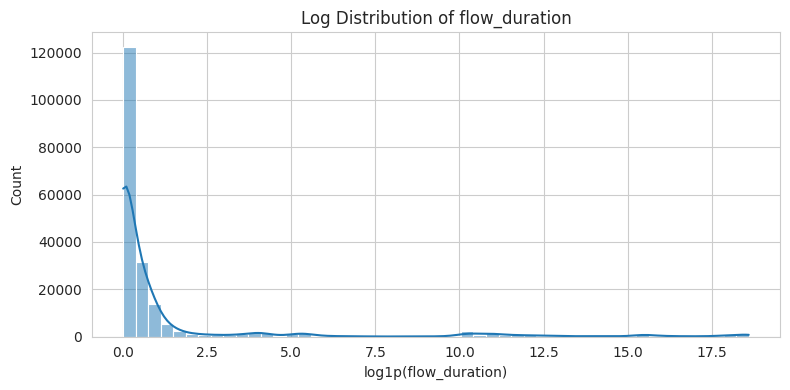

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


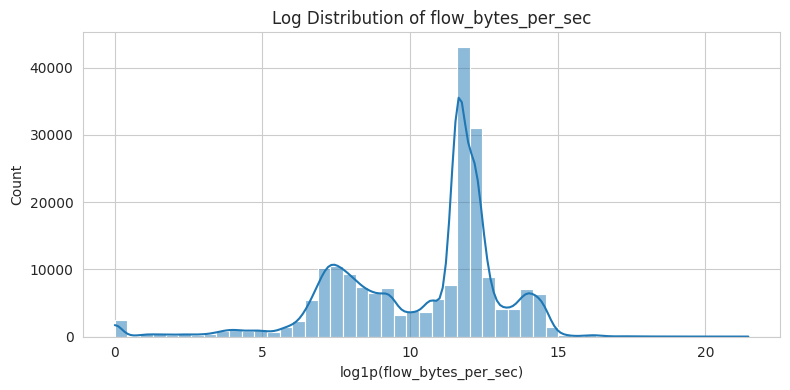

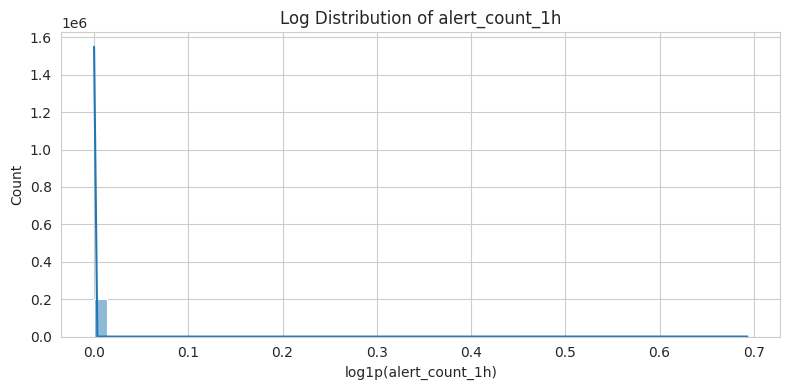

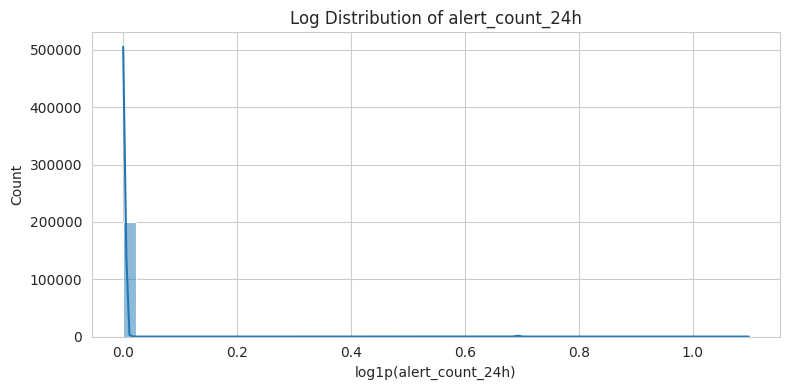

In [29]:
# Log Distribution for Skewed Features
skewed_features = [
    "flow_duration",
    "flow_bytes_per_sec",
    "alert_count_1h",
    "alert_count_24h"
]

for column in skewed_features:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        np.log1p(df[column]),
        bins=50,
        kde=True
    )

    plt.title(f"Log Distribution of {column}")
    plt.xlabel(f"log1p({column})")

    plt.tight_layout()
    plt.show()

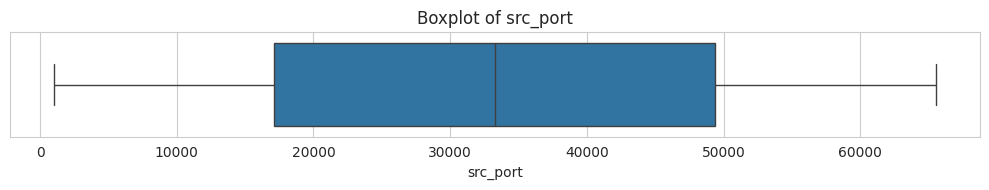

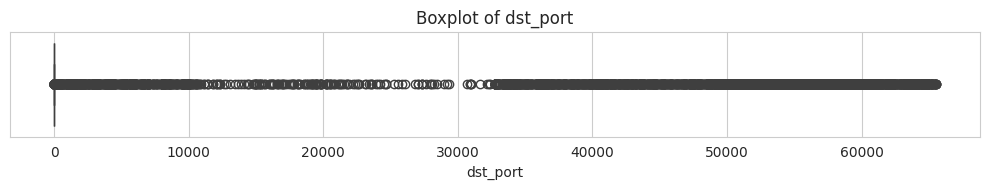

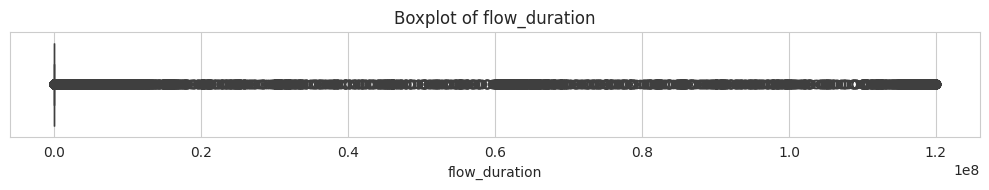

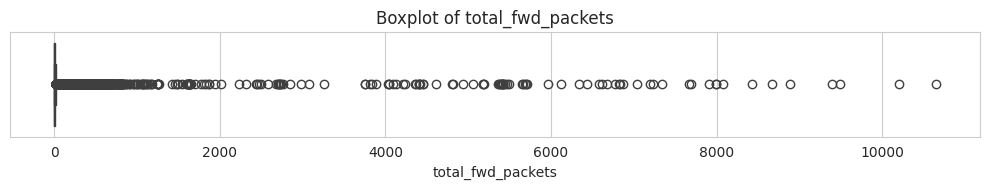

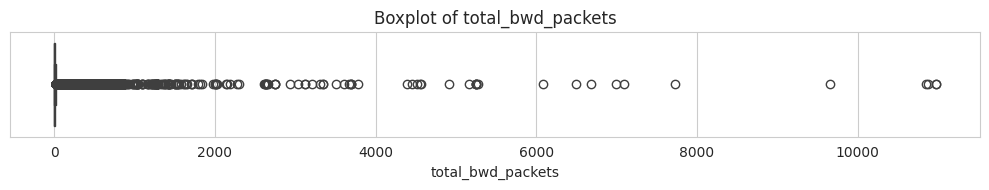

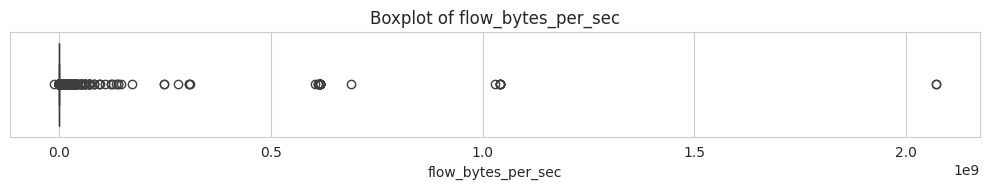

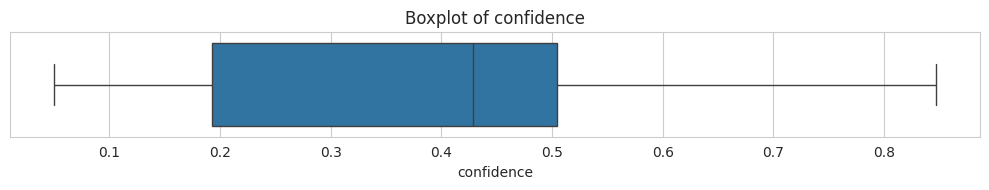

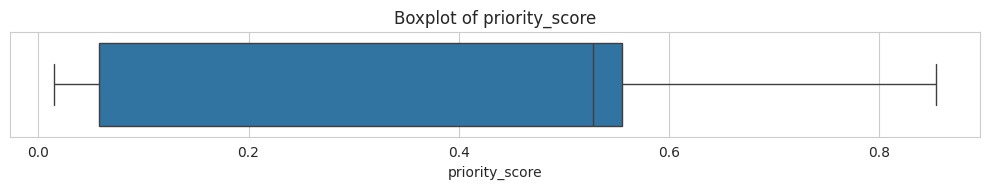

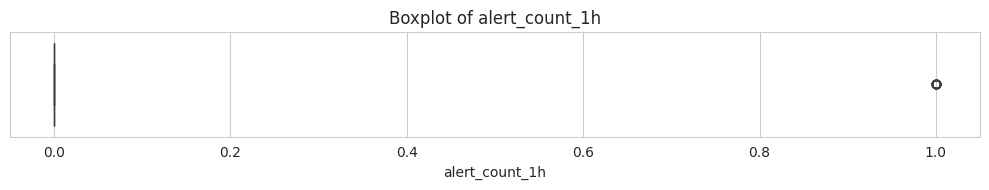

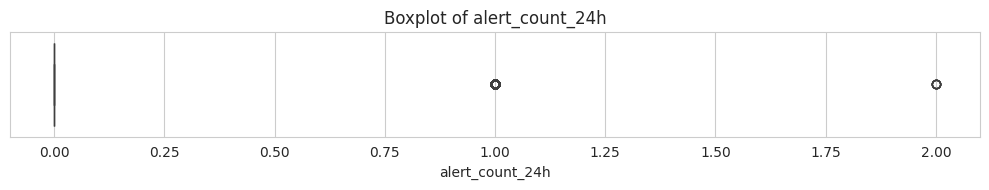

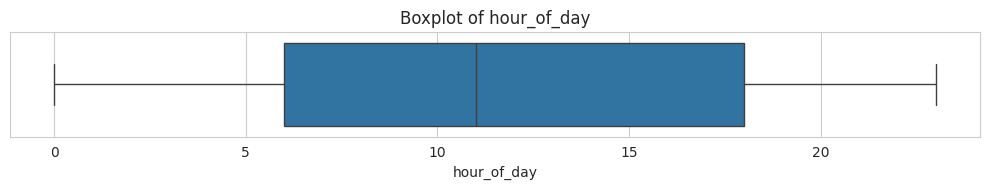

In [30]:
# Outlier Detection Using Boxplots
for column in numerical_cols:

    plt.figure(figsize=(10, 2))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

In [31]:
# IQR-Based Outlier Summary
outlier_summary = []

for column in numerical_cols:

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (
        (df[column] < lower) |
        (df[column] > upper)
    ).sum()

    outlier_summary.append([
        column,
        outliers,
        round(outliers / len(df) * 100, 2)
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Outlier Count",
        "Outlier Percentage"
    ]
)

display(outlier_df.sort_values(by="Outlier Percentage",ascending=False))

,Feature,Outlier Count,Outlier Percentage
2,flow_duration,29520,14.76
4,total_bwd_packets,25504,12.75
3,total_fwd_packets,25170,12.58
5,flow_bytes_per_sec,21668,10.83
1,dst_port,19623,9.81
9,alert_count_24h,650,0.32
8,alert_count_1h,28,0.01
0,src_port,0,0.00
6,confidence,0,0.00
7,priority_score,0,0.00


In [32]:
# Correlation Analysis
correlation_matrix = df[
    numerical_cols
].corr()

display(
    correlation_matrix.round(2)
)

,src_port,dst_port,flow_duration,total_fwd_packets,total_bwd_packets,flow_bytes_per_sec,confidence,priority_score,alert_count_1h,alert_count_24h,hour_of_day
src_port,1.0,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00
dst_port,0.0,1.00,0.04,-0.02,-0.02,0.08,-0.15,-0.16,0.02,0.05,-0.01
flow_duration,-0.0,0.04,1.00,0.01,-0.02,-0.00,-0.16,-0.14,0.00,0.04,0.01
total_fwd_packets,-0.0,-0.02,0.01,1.00,0.38,-0.00,-0.00,-0.01,-0.00,-0.01,0.00
total_bwd_packets,-0.0,-0.02,-0.02,0.38,1.00,0.00,-0.03,-0.05,-0.00,-0.01,0.00
flow_bytes_per_sec,0.0,0.08,-0.00,-0.00,0.00,1.00,-0.00,-0.02,0.00,0.01,0.00
confidence,-0.0,-0.15,-0.16,-0.00,-0.03,-0.00,1.00,0.95,-0.01,-0.05,-0.02
priority_score,-0.0,-0.16,-0.14,-0.01,-0.05,-0.02,0.95,1.00,-0.01,-0.05,-0.02
alert_count_1h,0.0,0.02,0.00,-0.00,-0.00,0.00,-0.01,-0.01,1.00,0.20,-0.00
alert_count_24h,0.0,0.05,0.04,-0.01,-0.01,0.01,-0.05,-0.05,0.20,1.00,0.00


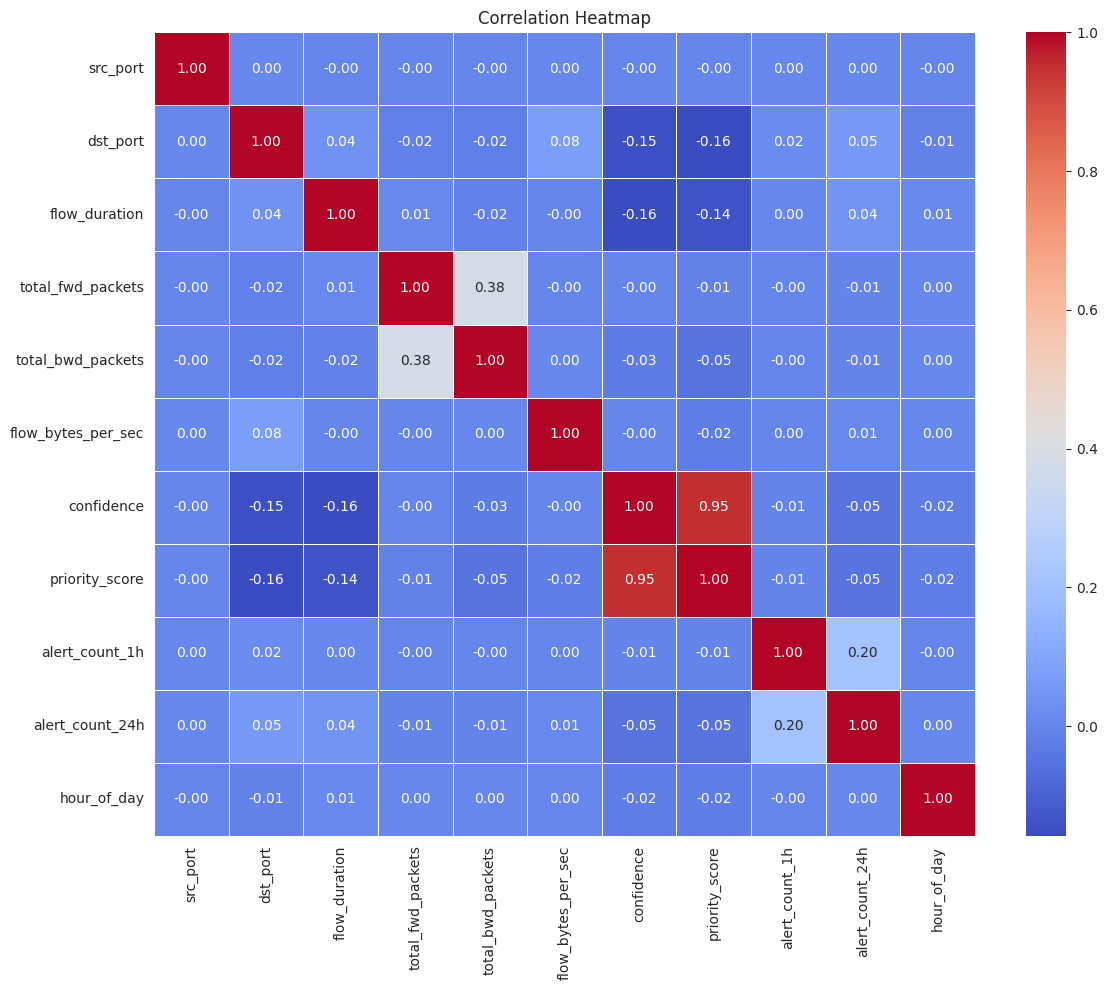

In [33]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [34]:
# Severity Analysis
severity_counts = (
    df["severity"]
    .value_counts()
    .reset_index()
)

severity_counts.columns = ["severity", "count"]

severity_counts["percentage"] = (
    severity_counts["count"] /
    len(df)
) * 100

display(severity_counts)

,severity,count,percentage
0,none,84734,42.3670
1,medium,58181,29.0905
2,high,42614,21.3070
3,low,11663,5.8315
4,critical,2808,1.4040


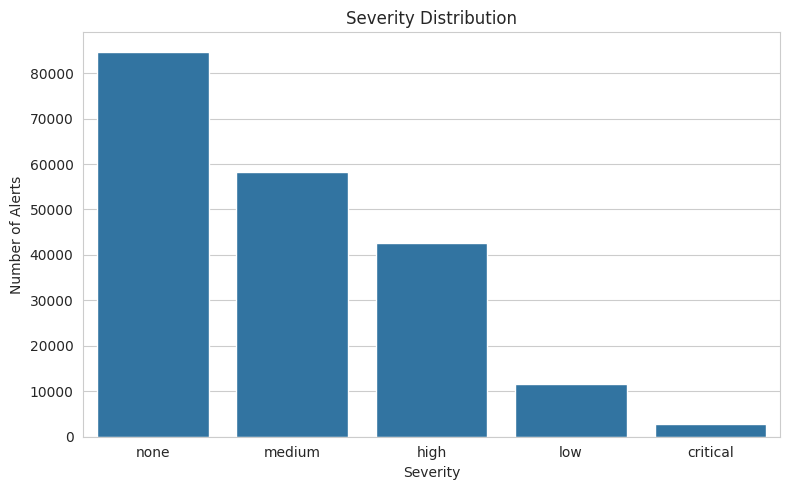

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="severity",
    order=df["severity"].value_counts().index
)

plt.title("Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Alerts")

plt.tight_layout()
plt.show()

In [36]:
# Alert Type Analysis
alert_type_counts = (
    df["alert_type"]
    .value_counts()
    .reset_index()
)

alert_type_counts.columns = [
    "alert_type",
    "count"
]

alert_type_counts["percentage"] = (
    alert_type_counts["count"] /
    len(df)
) * 100

display(alert_type_counts.head(20))

,alert_type,count,percentage
0,normal_traffic,84734,42.3670
1,generic_anomaly,41209,20.6045
2,exploit_attempt,31167,15.5835
3,fuzzing_attempt,16972,8.4860
4,denial_of_service,11447,5.7235
5,reconnaissance_scan,9790,4.8950
6,traffic_analysis,1873,0.9365
7,backdoor_activity,1630,0.8150
8,shellcode_execution,1057,0.5285
9,worm_propagation,121,0.0605


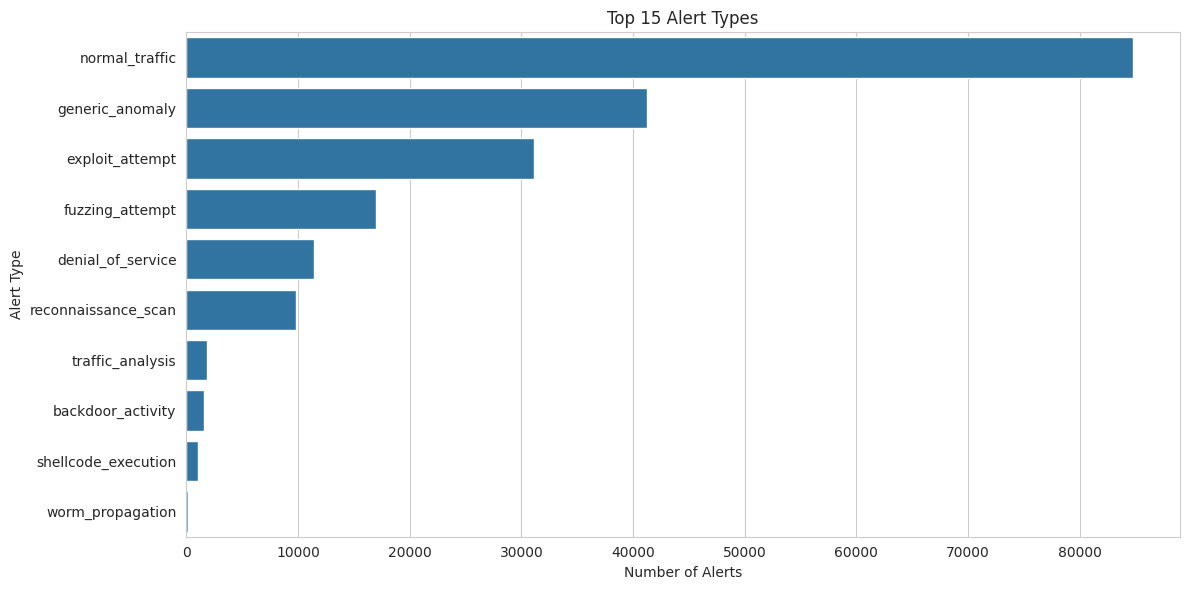

In [37]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    y="alert_type",
    order=df["alert_type"]
            .value_counts()
            .head(15)
            .index
)

plt.title("Top 15 Alert Types")
plt.xlabel("Number of Alerts")
plt.ylabel("Alert Type")

plt.tight_layout()
plt.show()

In [38]:
# MITRE ATT&CK Tactic Distribution
mitre_tactic_counts = (
    df["mitre_tactic"]
    .value_counts()
    .reset_index()
)

mitre_tactic_counts.columns = [
    "mitre_tactic",
    "count"
]

mitre_tactic_counts["percentage"] = (
    mitre_tactic_counts["count"] /
    len(df)
) * 100

display(mitre_tactic_counts)

,mitre_tactic,count,percentage
0,-,125943,62.9715
1,Execution,32224,16.1120
2,Discovery,18845,9.4225
3,Impact,11447,5.7235
4,Reconnaissance,9790,4.8950
5,Persistence,1630,0.8150
6,Lateral Movement,121,0.0605


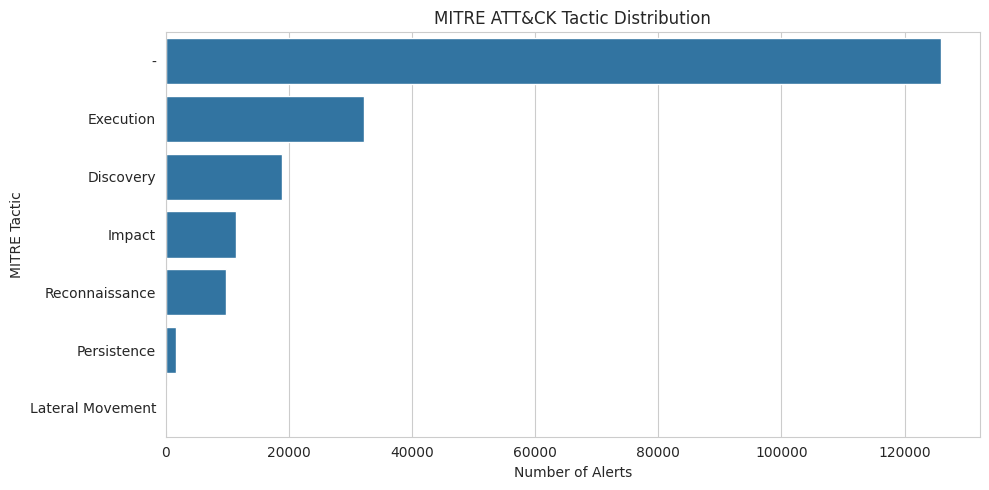

In [39]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="mitre_tactic",
    order=df["mitre_tactic"]
            .value_counts()
            .index
)

plt.title("MITRE ATT&CK Tactic Distribution")
plt.xlabel("Number of Alerts")
plt.ylabel("MITRE Tactic")

plt.tight_layout()
plt.show()

In [40]:
# MITRE ATT&CK Technique Distribution
mitre_technique_counts = (
    df["mitre_technique"]
    .value_counts()
    .reset_index()
)

mitre_technique_counts.columns = [
    "mitre_technique",
    "count"
]

mitre_technique_counts["percentage"] = (
    mitre_technique_counts["count"] /
    len(df)
) * 100

display(mitre_technique_counts.head(20))

,mitre_technique,count,percentage
0,-,125943,62.9715
1,T1203,31167,15.5835
2,T1046,16972,8.4860
3,T1499,11447,5.7235
4,T1595,9790,4.8950
5,T1040,1873,0.9365
6,T1547,1630,0.8150
7,T1059,1057,0.5285
8,T1210,121,0.0605


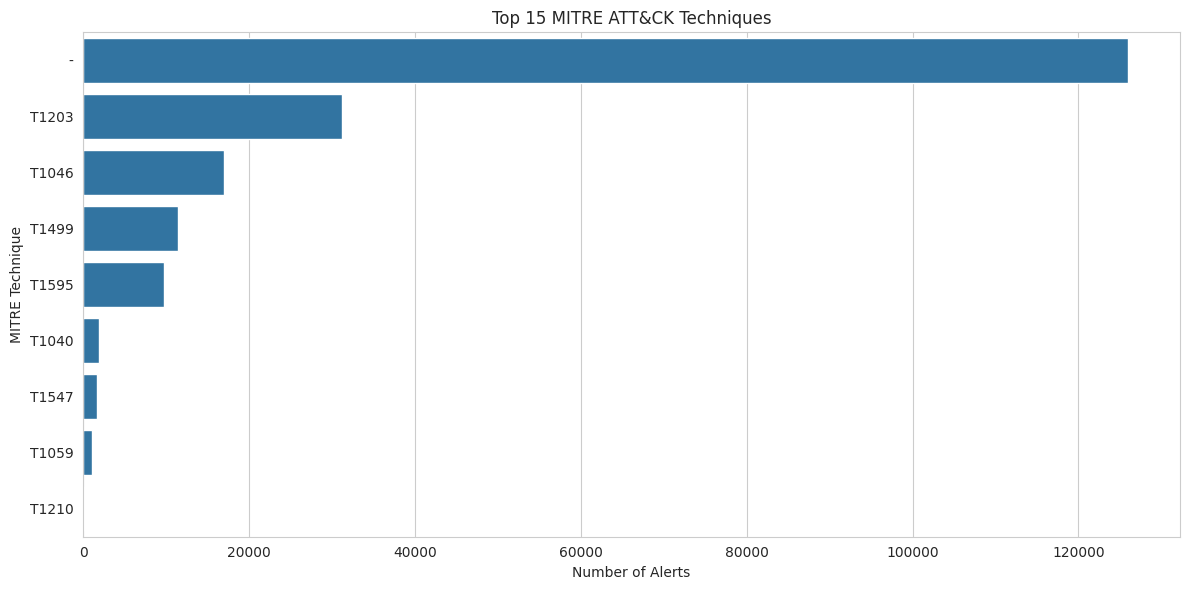

In [41]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="mitre_technique",
    order=df["mitre_technique"]
            .value_counts()
            .head(15)
            .index
)

plt.title("Top 15 MITRE ATT&CK Techniques")
plt.xlabel("Number of Alerts")
plt.ylabel("MITRE Technique")

plt.tight_layout()
plt.show()

In [42]:
# Kill-Chain Phase Analysis
kill_chain_counts = (
    df["kill_chain_phase"]
    .value_counts()
    .reset_index()
)

kill_chain_counts.columns = [
    "kill_chain_phase",
    "count"
]

kill_chain_counts["percentage"] = (
    kill_chain_counts["count"] /
    len(df)
) * 100

display(kill_chain_counts)

,kill_chain_phase,count,percentage
0,-,84734,42.3670
1,unknown,41209,20.6045
2,exploitation,32224,16.1120
3,reconnaissance,28635,14.3175
4,actions_on_objectives,11568,5.7840
5,installation,1630,0.8150


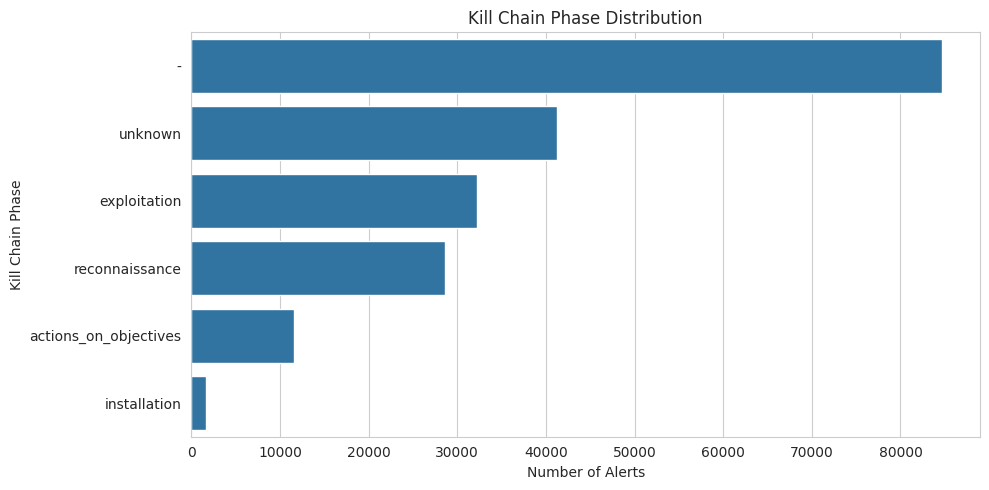

In [43]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="kill_chain_phase",
    order=df["kill_chain_phase"]
            .value_counts()
            .index
)

plt.title("Kill Chain Phase Distribution")
plt.xlabel("Number of Alerts")
plt.ylabel("Kill Chain Phase")

plt.tight_layout()
plt.show()

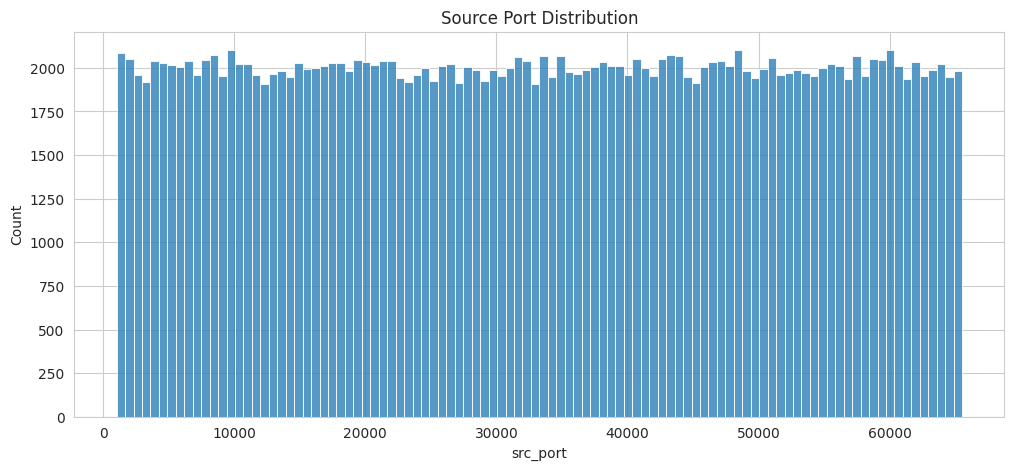

In [44]:
# Source Port Distribution
plt.figure(figsize=(12,5))
sns.histplot(df["src_port"], bins=100)
plt.title("Source Port Distribution")
plt.show()

In [45]:
print(df["src_port"].describe())

count    200000.000000
mean      33260.984880
std       18638.273268
min        1024.000000
25%       17119.750000
50%       33314.000000
75%       49371.250000
max       65534.000000
Name: src_port, dtype: float64


In [46]:
display(df["dst_port"].value_counts().head(20))

,count
dst_port,
0,180377
53,8267
443,4469
80,2000
123,190
389,61
22,58
88,44
21,30


In [47]:
display(df["src_port"].value_counts().head(20))

,count
src_port,
19034,13
54724,12
34936,12
47885,12
55257,12
18972,11
6990,11
64417,11
44174,11


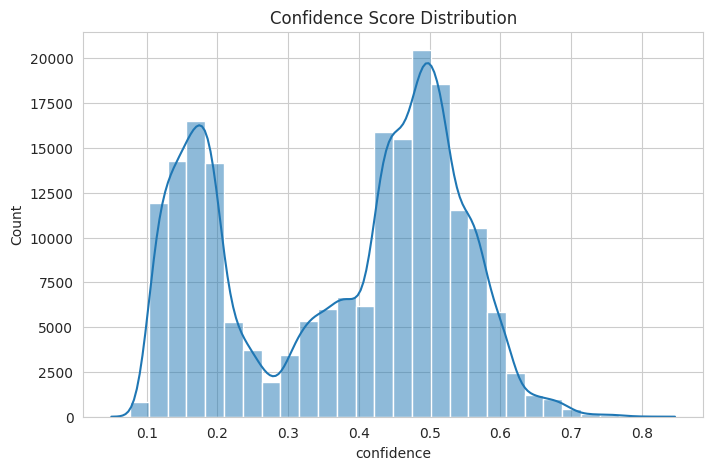

count    200000.000000
mean          0.372574
std           0.161577
min           0.050000
25%           0.192800
50%           0.428300
75%           0.504100
max           0.846900
Name: confidence, dtype: float64


In [48]:
# Confidence Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["confidence"], bins=30, kde=True)
plt.title("Confidence Score Distribution")
plt.show()

print(df["confidence"].describe())

In [49]:
# Attack Duration Analysis
print(df["flow_duration"].describe())

print(df["flow_duration"].quantile([0.25,0.5,0.75,0.90,0.95,0.99]))

count    2.000000e+05
mean     1.204399e+06
std      1.049386e+07
min     -1.000000e+00
25%      8.000000e-06
50%      2.676950e-02
75%      1.006932e+00
max      1.199995e+08
Name: flow_duration, dtype: float64
0.25    8.000000e-06
0.50    2.676950e-02
0.75    1.006932e+00
0.90    3.674801e+01
0.95    3.518395e+04
0.99    6.095429e+07
Name: flow_duration, dtype: float64


## Data Pre-processing and Feature Engineering


In [50]:
# libraries required for pre-processing and modelling
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [51]:
model_df = df.copy()

# --- TARGET LEAKAGE.
leakage_cols = [
    "priority_score",     # computed from severity/confidence at triage time
    "is_malicious",       # ground-truth flag the triage rule is built on
    "severity",           # maps ~1:1 to escalate / investigate / suppress
    "confidence",         # triage-time confidence score
    "alert_type",         # e.g. Benign -> suppress hard rule
    "attack_category",    # encodes malicious vs benign
    "mitre_tactic",       # only populated for attacks -> leaks the split
    "mitre_technique",
    "kill_chain_phase",
    "difficulty_level",   # derived from confidence bands
]

identifier_cols = [
    "alert_id",
    "src_ip",
    "dst_ip",
    "correlation_key",
    "alert_description",
    "timestamp",
]

other_drop_cols = ["source_dataset", "network_segment"]

drop_cols = leakage_cols + identifier_cols + other_drop_cols

model_df = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])

print("Dropped columns:", drop_cols)
print("Remaining columns:", model_df.shape[1])
print("Remaining feature list:", model_df.columns.tolist())


Dropped columns: ['priority_score', 'is_malicious', 'severity', 'confidence', 'alert_type', 'attack_category', 'mitre_tactic', 'mitre_technique', 'kill_chain_phase', 'difficulty_level', 'alert_id', 'src_ip', 'dst_ip', 'correlation_key', 'alert_description', 'timestamp', 'source_dataset', 'network_segment']
Remaining columns: 13
Remaining feature list: ['src_port', 'dst_port', 'protocol', 'flow_duration', 'total_fwd_packets', 'total_bwd_packets', 'flow_bytes_per_sec', 'triage_decision', 'alert_count_1h', 'alert_count_24h', 'is_repeated_target', 'hour_of_day', 'day_of_week']


In [52]:
# Reduce cardinality of 'protocol' (133 unique values) to the top 6 + 'other'
top_protocols = (
    model_df["protocol"]
    .value_counts()
    .head(6)
    .index
    .tolist()
)

model_df["protocol"] = model_df["protocol"].where(
    model_df["protocol"].isin(top_protocols),
    other="other"
)

print("Protocol categories retained:", top_protocols + ["other"])

Protocol categories retained: ['tcp', 'udp', 'unas', 'arp', 'ospf', 'sctp', 'other']


In [53]:
# Convert boolean flag to integer (0/1)
model_df["is_repeated_target"] = model_df["is_repeated_target"].astype(int)

In [54]:
# Log-transform highly skewed numerical features
skewed_features = [
    "flow_duration",
    "flow_bytes_per_sec",
    "alert_count_1h",
    "alert_count_24h"
]

model_df[skewed_features] = np.log1p(model_df[skewed_features])

print("Applied log1p transform to:", skewed_features)

Applied log1p transform to: ['flow_duration', 'flow_bytes_per_sec', 'alert_count_1h', 'alert_count_24h']


/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


In [55]:
# Encode the target variable (triage_decision) into numeric labels
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(model_df["triage_decision"])

# Class mapping
class_names = label_encoder.classes_
print("Target class mapping:")
for code_value, name in enumerate(class_names):
    print(f"  {code_value} -> {name}")

Target class mapping:
  0 -> escalate
  1 -> investigate
  2 -> suppress


In [56]:
# Separate the target from the feature set
feature_df = model_df.drop(columns=["triage_decision"])

# Identify categorical columns to one-hot encode
categorical_features = feature_df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical features to encode:", categorical_features)

Categorical features to encode: ['protocol', 'day_of_week']


In [57]:
# One-hot encode categorical features
X = pd.get_dummies(
    feature_df,
    columns=categorical_features,
    drop_first=False
)

# Ensure all dummy columns are numeric
X = X.astype(float)

print("Final feature matrix shape:", X.shape)
print("Total features after encoding:", X.shape[1])

Final feature matrix shape: (200000, 24)
Total features after encoding: 24


### Class Balancing (Triage Decision)


In [58]:
# Balance the three triage classes by undersampling the two majority classes
undersampler = RandomUnderSampler(
    sampling_strategy="auto",   # resample all classes down to the minority count
    random_state=42
)

X_balanced, y_balanced = undersampler.fit_resample(X, y)

print("Balanced feature matrix shape:", X_balanced.shape)
print("Balanced class distribution:")
display(pd.Series(y_balanced).map(
    dict(enumerate(class_names))
).value_counts())


Balanced feature matrix shape: (136266, 24)
Balanced class distribution:


,count
escalate,45422
investigate,45422
suppress,45422


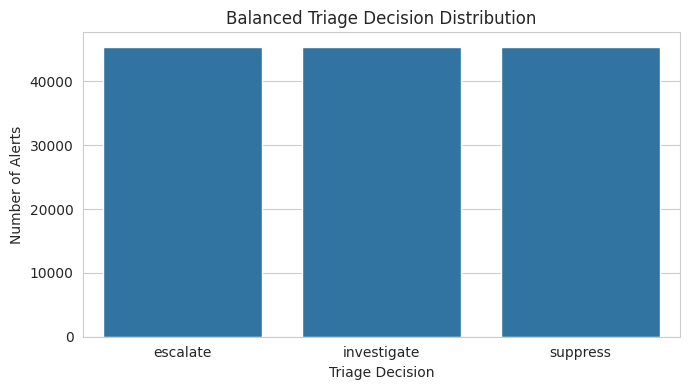

In [59]:
# Visualise the balanced target distribution
plt.figure(figsize=(7, 4))

sns.countplot(
    x=pd.Series(y_balanced).map(dict(enumerate(class_names))),
    order=class_names
)

plt.title("Balanced Triage Decision Distribution")
plt.xlabel("Triage Decision")
plt.ylabel("Number of Alerts")

plt.tight_layout()
plt.show()

### Train / Validation / Test Split

In [60]:
# First split: separate the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.15,
    random_state=42,
    stratify=y_balanced
)

# Second split: separate validation (15% of total) from the remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val   shape: {X_val.shape}")
print(f"X_test  shape: {X_test.shape}")

X_train shape: (95382, 24)
X_val   shape: (20444, 24)
X_test  shape: (20440, 24)


### Feature Scaling

In [61]:
import numpy as np

# Replace any infinite values (from log1p of negative numbers) with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Impute NaN values with the median of their respective columns
for col in X_train.columns:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_val[col] = X_val[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Standardise features (fit on train only)
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Scaling complete.")
print("Scaled training matrix shape:", X_train_scaled.shape)

Scaling complete.
Scaled training matrix shape: (95382, 24)


## Modelling

### Model 1 - Random Forest

In [62]:
# Initialise the Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

In [63]:
# Train the Random Forest on the scaled training data
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [64]:
# Generate predictions and class probabilities on the test set
rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)

In [65]:
# Evaluate the Random Forest
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average="macro", zero_division=0)
rf_rec = recall_score(y_test, rf_pred, average="macro", zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average="macro", zero_division=0)
rf_auc = roc_auc_score(y_test, rf_proba, multi_class="ovr", average="macro")

# Macro False Positive Rate from the confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)
rf_fp = rf_cm.sum(axis=0) - np.diag(rf_cm)
rf_fn = rf_cm.sum(axis=1) - np.diag(rf_cm)
rf_tp = np.diag(rf_cm)
rf_tn = rf_cm.sum() - (rf_fp + rf_fn + rf_tp)
rf_fpr = (rf_fp / (rf_fp + rf_tn)).mean()

print("Random Forest - Classification Report")
print(classification_report(y_test, rf_pred, target_names=class_names, zero_division=0))
print(f"Accuracy : {rf_acc:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")
print(f"FPR      : {rf_fpr:.4f}")

Random Forest - Classification Report
              precision    recall  f1-score   support

    escalate       0.84      0.92      0.88      6813
 investigate       0.89      0.83      0.86      6813
    suppress       0.94      0.91      0.93      6814

    accuracy                           0.89     20440
   macro avg       0.89      0.89      0.89     20440
weighted avg       0.89      0.89      0.89     20440

Accuracy : 0.8865
ROC-AUC  : 0.9709
FPR      : 0.0567


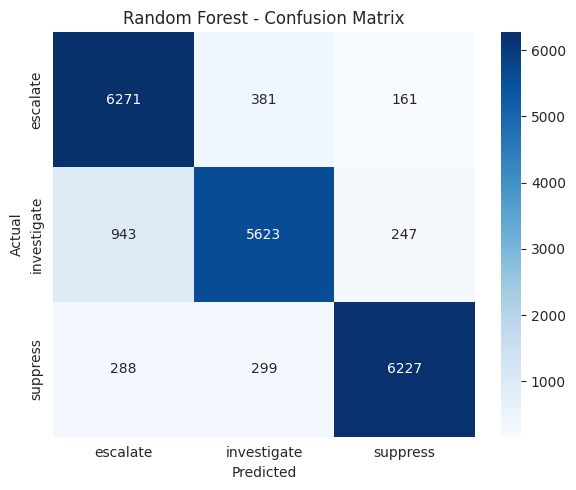

In [66]:
# Confusion matrix - Random Forest
plt.figure(figsize=(6, 5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Model 2 - XGBoost

In [67]:
# Initialise the XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42
)

In [68]:
# Train the XGBoost model
xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

In [69]:
# Generate predictions and class probabilities on the test set
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_proba = xgb_model.predict_proba(X_test_scaled)

In [70]:
# Evaluate XGBoost
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred, average="macro", zero_division=0)
xgb_rec = recall_score(y_test, xgb_pred, average="macro", zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, average="macro", zero_division=0)
xgb_auc = roc_auc_score(y_test, xgb_proba, multi_class="ovr", average="macro")

xgb_cm = confusion_matrix(y_test, xgb_pred)
xgb_fp = xgb_cm.sum(axis=0) - np.diag(xgb_cm)
xgb_fn = xgb_cm.sum(axis=1) - np.diag(xgb_cm)
xgb_tp = np.diag(xgb_cm)
xgb_tn = xgb_cm.sum() - (xgb_fp + xgb_fn + xgb_tp)
xgb_fpr = (xgb_fp / (xgb_fp + xgb_tn)).mean()

print("XGBoost - Classification Report")
print(classification_report(y_test, xgb_pred, target_names=class_names, zero_division=0))
print(f"Accuracy : {xgb_acc:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")
print(f"FPR      : {xgb_fpr:.4f}")

XGBoost - Classification Report
              precision    recall  f1-score   support

    escalate       0.84      0.93      0.88      6813
 investigate       0.91      0.82      0.86      6813
    suppress       0.93      0.92      0.93      6814

    accuracy                           0.89     20440
   macro avg       0.89      0.89      0.89     20440
weighted avg       0.89      0.89      0.89     20440

Accuracy : 0.8919
ROC-AUC  : 0.9748
FPR      : 0.0540


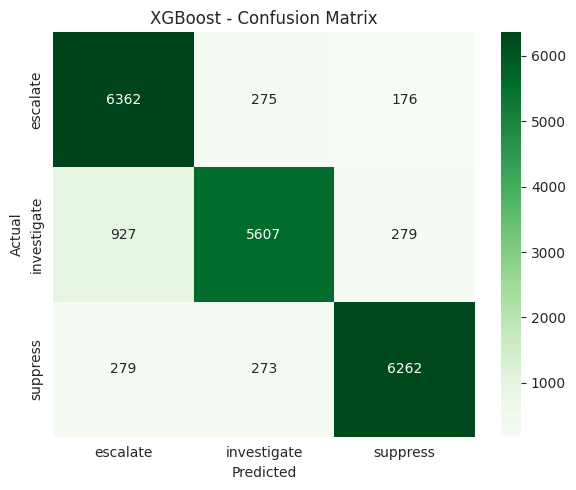

In [71]:
# Confusion matrix - XGBoost
plt.figure(figsize=(6, 5))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Model 3 - Custom Deep Neural Network


In [72]:
# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
tf.random.set_seed(42)

# Convert data to float32 arrays for Keras
X_train_arr = X_train_scaled.values.astype("float32")
X_val_arr = X_val_scaled.values.astype("float32")
X_test_arr = X_test_scaled.values.astype("float32")

y_train_arr = y_train.astype("int32")
y_val_arr = y_val.astype("int32")
y_test_arr = y_test.astype("int32")

In [73]:
# Build the deep neural network architecture
dnn_model = Sequential()

dnn_model.add(Input(shape=(X_train_arr.shape[1],)))
dnn_model.add(Dense(128, activation="relu"))
dnn_model.add(Dropout(0.3))
dnn_model.add(Dense(64, activation="relu"))
dnn_model.add(Dropout(0.2))
dnn_model.add(Dense(32, activation="relu"))
dnn_model.add(Dense(3, activation="softmax"))

dnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,635 (53.26 KB)

 Trainable params: 13,635 (53.26 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# Train the DNN with early stopping on validation loss
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

dnn_history = dnn_model.fit(
    X_train_arr,
    y_train_arr,
    validation_data=(X_val_arr, y_val_arr),
    epochs=10,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7014 - loss: 0.6767 - val_accuracy: 0.7488 - val_loss: 0.5771
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7500 - loss: 0.5895 - val_accuracy: 0.7824 - val_loss: 0.5308
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7723 - loss: 0.5451 - val_accuracy: 0.7926 - val_loss: 0.4989
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7877 - loss: 0.5151 - val_accuracy: 0.8079 - val_loss: 0.4701
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7990 - loss: 0.4913 - val_accuracy: 0.8165 - val_loss: 0.4480
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8045 - loss: 0.4737 - val_accuracy: 0.8250 - val_loss: 0.4354
Epoch 7/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8118 - loss: 0.4594 - val_accuracy: 0.8284 - val_loss: 0.4207
Epoch 8/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8162 - loss: 0.4490 - val_accuracy: 0.

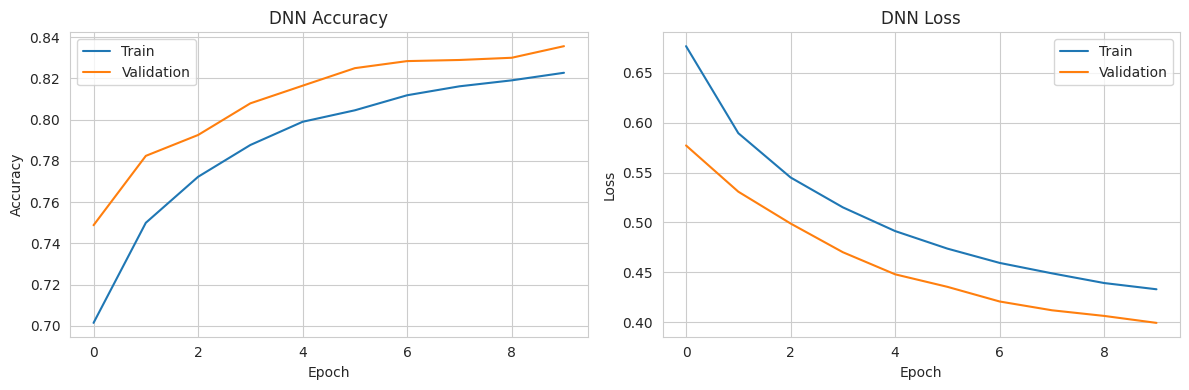

In [75]:
# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(dnn_history.history["accuracy"], label="Train")
plt.plot(dnn_history.history["val_accuracy"], label="Validation")
plt.title("DNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(dnn_history.history["loss"], label="Train")
plt.plot(dnn_history.history["val_loss"], label="Validation")
plt.title("DNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [76]:
# Generate predictions and class probabilities on the test set
dnn_proba = dnn_model.predict(X_test_arr)
dnn_pred = np.argmax(dnn_proba, axis=1)

639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step


In [77]:
# Evaluate the DNN
dnn_acc = accuracy_score(y_test_arr, dnn_pred)
dnn_prec = precision_score(y_test_arr, dnn_pred, average="macro", zero_division=0)
dnn_rec = recall_score(y_test_arr, dnn_pred, average="macro", zero_division=0)
dnn_f1 = f1_score(y_test_arr, dnn_pred, average="macro", zero_division=0)
dnn_auc = roc_auc_score(y_test_arr, dnn_proba, multi_class="ovr", average="macro")

dnn_cm = confusion_matrix(y_test_arr, dnn_pred)
dnn_fp = dnn_cm.sum(axis=0) - np.diag(dnn_cm)
dnn_fn = dnn_cm.sum(axis=1) - np.diag(dnn_cm)
dnn_tp = np.diag(dnn_cm)
dnn_tn = dnn_cm.sum() - (dnn_fp + dnn_fn + dnn_tp)
dnn_fpr = (dnn_fp / (dnn_fp + dnn_tn)).mean()

print("Deep Neural Network - Classification Report")
print(classification_report(y_test_arr, dnn_pred, target_names=class_names, zero_division=0))
print(f"Accuracy : {dnn_acc:.4f}")
print(f"ROC-AUC  : {dnn_auc:.4f}")
print(f"FPR      : {dnn_fpr:.4f}")

Deep Neural Network - Classification Report
              precision    recall  f1-score   support

    escalate       0.80      0.84      0.82      6813
 investigate       0.86      0.78      0.82      6813
    suppress       0.85      0.88      0.86      6814

    accuracy                           0.84     20440
   macro avg       0.84      0.84      0.83     20440
weighted avg       0.84      0.84      0.83     20440

Accuracy : 0.8352
ROC-AUC  : 0.9533
FPR      : 0.0824


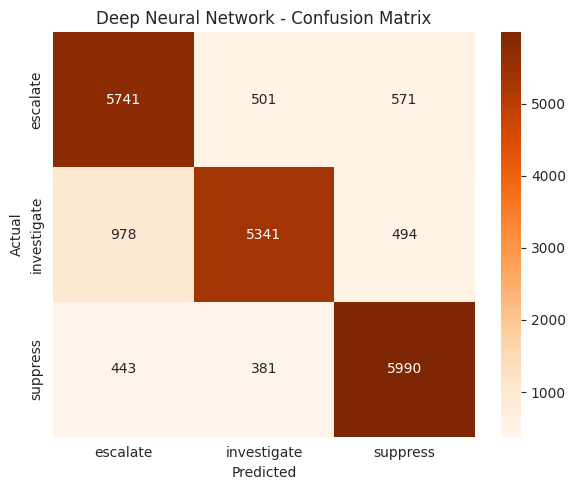

In [78]:
# Confusion matrix - DNN
plt.figure(figsize=(6, 5))
sns.heatmap(
    dnn_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Deep Neural Network - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Model 4 - Logistic Regression

In [95]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Initialise the Logistic Regression classifier
lr_model = LogisticRegression(
    random_state=42,
    multi_class='multinomial', # For multi-class classification
    solver='lbfgs',            # Algorithm to use for optimization
    max_iter=1000              # Increased max_iter for convergence
)

In [96]:
# Train the Logistic Regression model
lr_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [97]:
# Generate predictions and class probabilities on the test set
lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)

In [98]:
# Evaluate Logistic Regression
lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, average="macro", zero_division=0)
lr_rec = recall_score(y_test, lr_pred, average="macro", zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, average="macro", zero_division=0)
lr_auc = roc_auc_score(y_test, lr_proba, multi_class="ovr", average="macro")

lr_cm = confusion_matrix(y_test, lr_pred)
lr_fp = lr_cm.sum(axis=0) - np.diag(lr_cm)
lr_fn = lr_cm.sum(axis=1) - np.diag(lr_cm)
lr_tp = np.diag(lr_cm)
lr_tn = lr_cm.sum() - (lr_fp + lr_fn + lr_tp)
lr_fpr = (lr_fp / (lr_fp + lr_tn)).mean()

print("Logistic Regression - Classification Report")
print(classification_report(y_test, lr_pred, target_names=class_names, zero_division=0))
print(f"Accuracy : {lr_acc:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")
print(f"FPR      : {lr_fpr:.4f}")

Logistic Regression - Classification Report
              precision    recall  f1-score   support

    escalate       0.66      0.75      0.70      6813
 investigate       0.74      0.72      0.73      6813
    suppress       0.71      0.62      0.66      6814

    accuracy                           0.70     20440
   macro avg       0.70      0.70      0.70     20440
weighted avg       0.70      0.70      0.70     20440

Accuracy : 0.6982
ROC-AUC  : 0.8828
FPR      : 0.1509


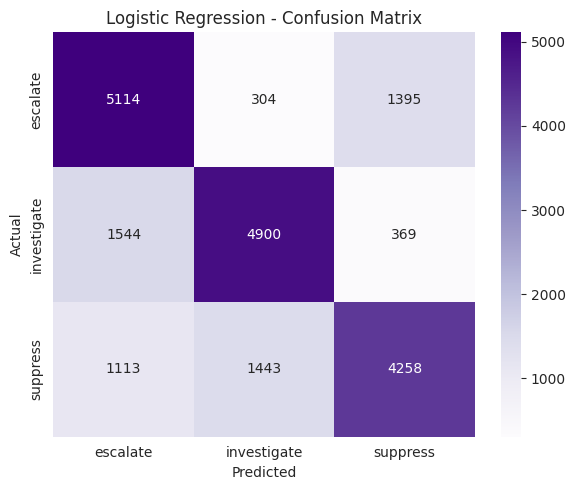

In [99]:
# Confusion matrix - Logistic Regression
plt.figure(figsize=(6, 5))
sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Adversarial Robustness Testing

In [79]:
# Generate an adversarial version of the test set
rng = np.random.default_rng(42)
epsilon = 0.5

X_test_adv = X_test_arr + rng.normal(
    loc=0.0,
    scale=epsilon,
    size=X_test_arr.shape
).astype("float32")

In [80]:
# Baseline DNN performance: clean vs adversarial test data
base_clean_pred = np.argmax(dnn_model.predict(X_test_arr), axis=1)
base_adv_pred = np.argmax(dnn_model.predict(X_test_adv), axis=1)

base_clean_acc = accuracy_score(y_test_arr, base_clean_pred)
base_adv_acc = accuracy_score(y_test_arr, base_adv_pred)

print(f"Baseline DNN - Clean Accuracy       : {base_clean_acc:.4f}")
print(f"Baseline DNN - Adversarial Accuracy : {base_adv_acc:.4f}")
print(f"Robustness Gap                      : {base_clean_acc - base_adv_acc:.4f}")

639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Baseline DNN - Clean Accuracy       : 0.8352
Baseline DNN - Adversarial Accuracy : 0.5290
Robustness Gap                      : 0.3062


In [81]:
# Build an adversarially-augmented training set
X_train_adv = X_train_arr + rng.normal(
    loc=0.0,
    scale=epsilon,
    size=X_train_arr.shape
).astype("float32")

X_train_aug = np.concatenate([X_train_arr, X_train_adv], axis=0)
y_train_aug = np.concatenate([y_train_arr, y_train_arr], axis=0)

sample_weights = np.concatenate([
    np.ones(X_train_arr.shape[0]),
    np.full(X_train_adv.shape[0], 2.0)
]).astype("float32")

print("Augmented training set shape:", X_train_aug.shape)

Augmented training set shape: (190764, 24)


In [82]:
# Train the adversarially-weighted DNN
tf.random.set_seed(42)

dnn_adv_model = Sequential()
dnn_adv_model.add(Input(shape=(X_train_aug.shape[1],)))
dnn_adv_model.add(Dense(128, activation="relu"))
dnn_adv_model.add(Dropout(0.3))
dnn_adv_model.add(Dense(64, activation="relu"))
dnn_adv_model.add(Dropout(0.2))
dnn_adv_model.add(Dense(32, activation="relu"))
dnn_adv_model.add(Dense(3, activation="softmax"))

dnn_adv_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop_adv = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

dnn_adv_model.fit(
    X_train_aug,
    y_train_aug,
    sample_weight=sample_weights,
    validation_data=(X_val_arr, y_val_arr),
    epochs=10,
    batch_size=256,
    callbacks=[early_stop_adv],
    verbose=1
)

Epoch 1/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6905 - loss: 1.0549 - val_accuracy: 0.7290 - val_loss: 0.6046
Epoch 2/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7162 - loss: 0.9719 - val_accuracy: 0.7397 - val_loss: 0.5826
Epoch 3/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7238 - loss: 0.9489 - val_accuracy: 0.7477 - val_loss: 0.5600
Epoch 4/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7307 - loss: 0.9338 - val_accuracy: 0.7690 - val_loss: 0.5409
Epoch 5/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7355 - loss: 0.9223 - val_accuracy: 0.7804 - val_loss: 0.5212
Epoch 6/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7414 - loss: 0.9125 - val_accuracy: 0.7835 - val_loss: 0.5137
Epoch 7/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7439 - loss: 0.9043 - val_accuracy: 0.7893 - val_loss: 0.5018
Epoch 8/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7467 - loss: 0.8987 - val_accuracy: 0.

In [83]:
# Adversarially-weighted DNN: clean vs adversarial accuracy
adv_clean_pred = np.argmax(dnn_adv_model.predict(X_test_arr), axis=1)
adv_adv_pred = np.argmax(dnn_adv_model.predict(X_test_adv), axis=1)

adv_clean_acc = accuracy_score(y_test_arr, adv_clean_pred)
adv_adv_acc = accuracy_score(y_test_arr, adv_adv_pred)

print(f"Adversarially-Weighted DNN - Clean Accuracy       : {adv_clean_acc:.4f}")
print(f"Adversarially-Weighted DNN - Adversarial Accuracy : {adv_adv_acc:.4f}")
print(f"Robustness Gap                                    : {adv_clean_acc - adv_adv_acc:.4f}")

639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step
Adversarially-Weighted DNN - Clean Accuracy       : 0.7976
Adversarially-Weighted DNN - Adversarial Accuracy : 0.7188
Robustness Gap                                    : 0.0788


In [84]:
# Robustness comparison table
robustness_df = pd.DataFrame({
    "Model": ["Baseline DNN", "Adversarially-Weighted DNN"],
    "Clean Accuracy": [base_clean_acc, adv_clean_acc],
    "Adversarial Accuracy": [base_adv_acc, adv_adv_acc],
    "Robustness Gap": [
        base_clean_acc - base_adv_acc,
        adv_clean_acc - adv_adv_acc
    ]
}).round(4)

display(robustness_df)

,Model,Clean Accuracy,Adversarial Accuracy,Robustness Gap
0,Baseline DNN,0.8352,0.5290,0.3062
1,Adversarially-Weighted DNN,0.7976,0.7188,0.0788


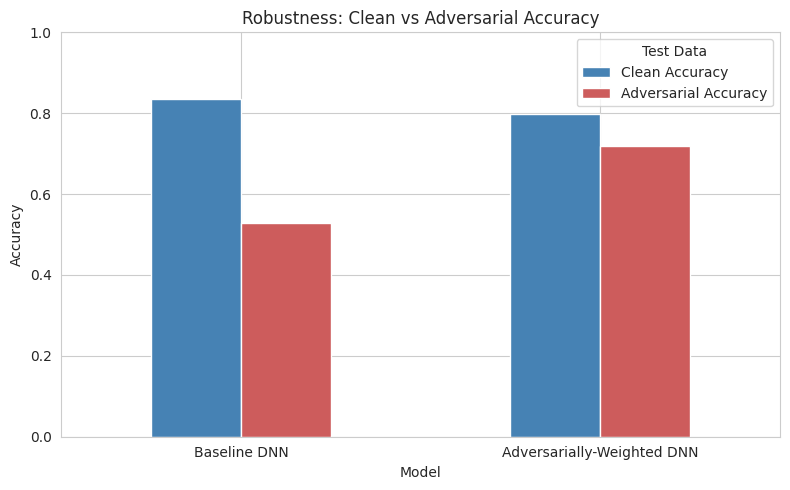

In [85]:
# Visualise clean vs adversarial accuracy before and after adversarial weighting
robustness_plot = robustness_df.set_index("Model")[
    ["Clean Accuracy", "Adversarial Accuracy"]
]

robustness_plot.plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "indianred"]
)

plt.title("Robustness: Clean vs Adversarial Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Test Data")
plt.tight_layout()
plt.show()

## Explainability with SHAP


In [86]:
# Install SHAP
!pip install shap -q

In [87]:
import shap

# Explain a random sample of the test set for efficiency
shap_sample = X_test_scaled.sample(n=500, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

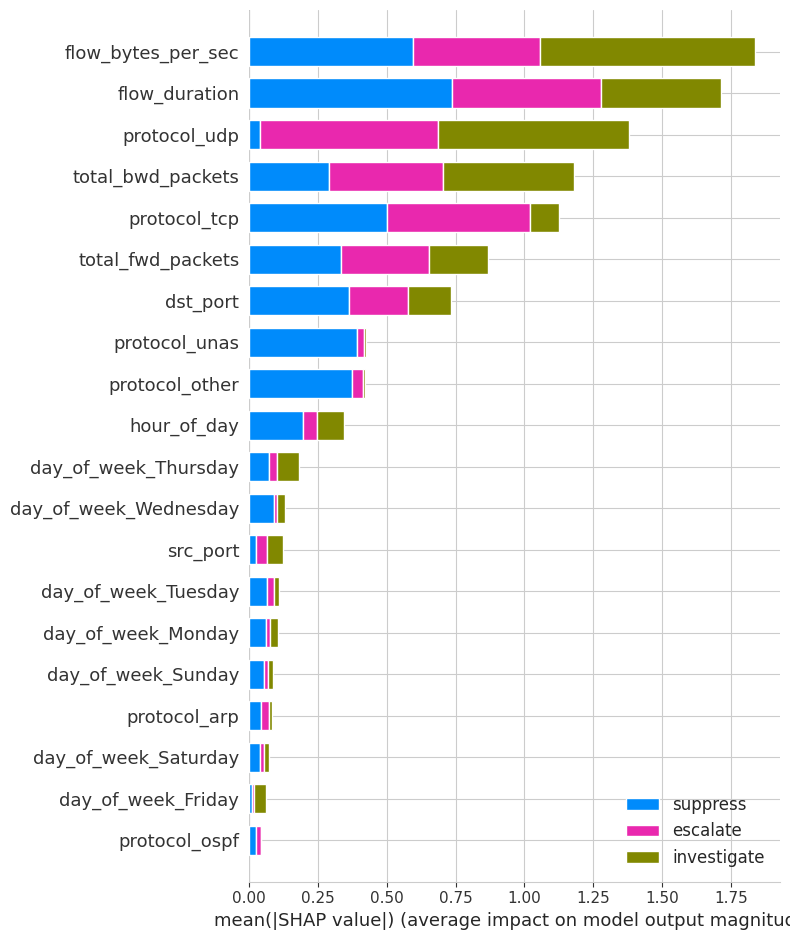

In [88]:
# Global feature importance (mean absolute SHAP value across classes)
shap.summary_plot(
    shap_values,
    shap_sample,
    plot_type="bar",
    class_names=class_names,
    show=True
)

## Model Comparison

In [100]:
# Consolidate all model results into a single comparison table
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Deep Neural Network", "Logistic Regression"],
    "Accuracy":  [rf_acc, xgb_acc, dnn_acc, lr_acc],
    "Precision": [rf_prec, xgb_prec, dnn_prec, lr_prec],
    "Recall":    [rf_rec, xgb_rec, dnn_rec, lr_rec],
    "F1-Score":  [rf_f1, xgb_f1, dnn_f1, lr_f1],
    "ROC-AUC":   [rf_auc, xgb_auc, dnn_auc, lr_auc],
    "FPR":       [rf_fpr, xgb_fpr, dnn_fpr, lr_fpr]
}).round(4)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,FPR
0,Random Forest,0.8865,0.8888,0.8865,0.8865,0.9709,0.0567
1,XGBoost,0.8919,0.8946,0.8919,0.8917,0.9748,0.0540
2,Deep Neural Network,0.8352,0.8363,0.8352,0.8349,0.9533,0.0824
3,Logistic Regression,0.6982,0.7008,0.6982,0.6976,0.8828,0.1509


In [101]:
# Highlight the best value in each metric column
styled_comparison = comparison_df.set_index("Model").style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    color="lightgreen"
).highlight_min(
    subset=["FPR"],
    color="lightgreen"
)

display(styled_comparison)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,FPR
Model,,,,,,
Random Forest,0.886500,0.888800,0.886500,0.886500,0.970900,0.056700
XGBoost,0.891900,0.894600,0.891900,0.891700,0.974800,0.054000
Deep Neural Network,0.835200,0.836300,0.835200,0.834900,0.953300,0.082400
Logistic Regression,0.698200,0.700800,0.698200,0.697600,0.882800,0.150900


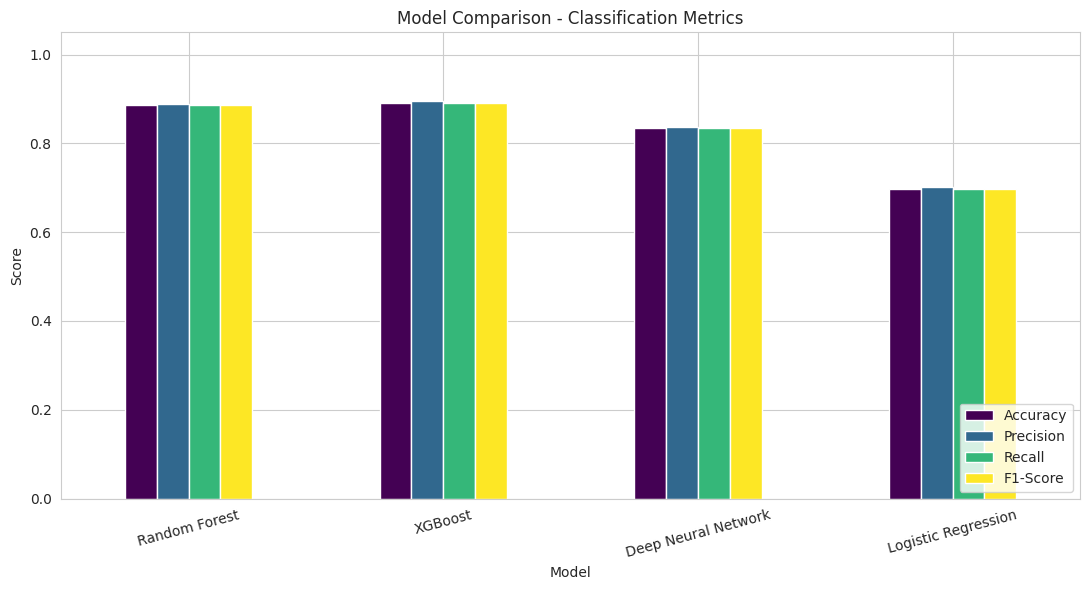

In [102]:
# Grouped bar chart: Accuracy, Precision, Recall, F1-Score
comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(11, 6),
    colormap="viridis"
)

plt.title("Model Comparison - Classification Metrics")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_9166/244309862.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


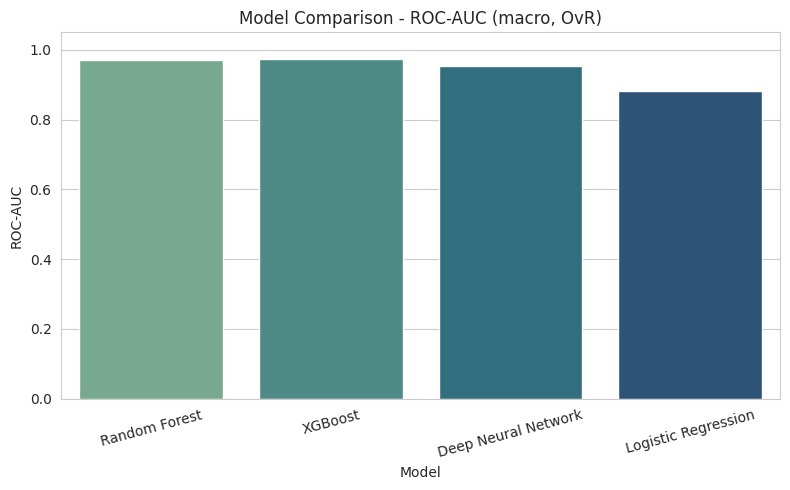

In [103]:
# ROC-AUC comparison
plt.figure(figsize=(8, 5))
sns.barplot(
    data=comparison_df,
    x="Model",
    y="ROC-AUC",
    palette="crest"
)
plt.title("Model Comparison - ROC-AUC (macro, OvR)")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [104]:
# Identify the best-performing model by F1-Score
best_model_row = comparison_df.loc[comparison_df["F1-Score"].idxmax()]
print("Best model by F1-Score:")
print(best_model_row.to_string())

Best model by F1-Score:
Model        XGBoost
Accuracy      0.8919
Precision     0.8946
Recall        0.8919
F1-Score      0.8917
ROC-AUC       0.9748
FPR            0.054
